# Unemployment Analysis with Python

## Internship Task

This project analyzes unemployment rate data using Python.  
The analysis includes:
- Data Cleaning
- Exploratory Data Analysis
- Visualization
- Covid-19 Impact Analysis
- Seasonal Trend Analysis

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12,6)

In [45]:
df = pd.read_csv("unemployment in india.csv")

In [46]:
df = pd.read_csv("unemployment_Rate_upto_11_2020.csv")

# Data Cleaning

In [47]:
# remove extra spaces from column names
df.columns = df.columns.str.strip()

# check cleaned column names
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')


In [48]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')


In [49]:
df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   267 non-null    str    
 1   Date                                     267 non-null    str    
 2   Frequency                                267 non-null    str    
 3   Estimated Unemployment Rate (%)          267 non-null    float64
 4   Estimated Employed                       267 non-null    int64  
 5   Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                 267 non-null    str    
 7   longitude                                267 non-null    float64
 8   latitude                                 267 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 18.9 KB


In [51]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


In [52]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64

In [53]:
df = df.dropna()

In [54]:
df = df.drop_duplicates()

In [55]:
df['Date'] = pd.to_datetime(df['Date'])

/var/folders/8n/j8wgm5f924s41_y6d7k5wf_00000gn/T/ipykernel_2298/2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [56]:
average_rate = df['Estimated Unemployment Rate (%)'].mean()

print("Average Unemployment Rate:", average_rate)

Average Unemployment Rate: 12.236928838951311


In [57]:
region_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

region_unemployment.sort_values(ascending=False)

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64

# Data Visualization

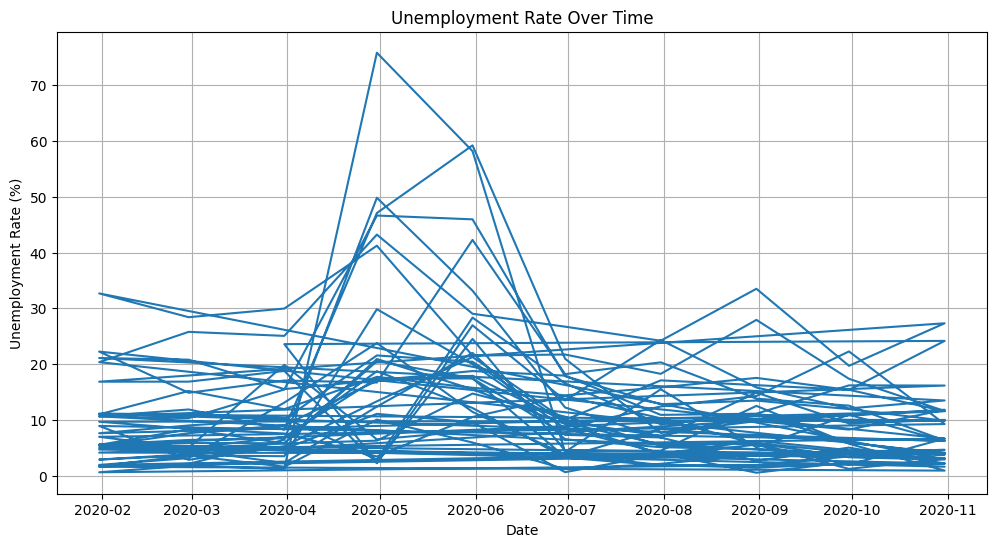

In [58]:
plt.plot(
    df['Date'],
    df['Estimated Unemployment Rate (%)']
)

plt.title("Unemployment Rate Over Time")

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.grid(True)

plt.show()

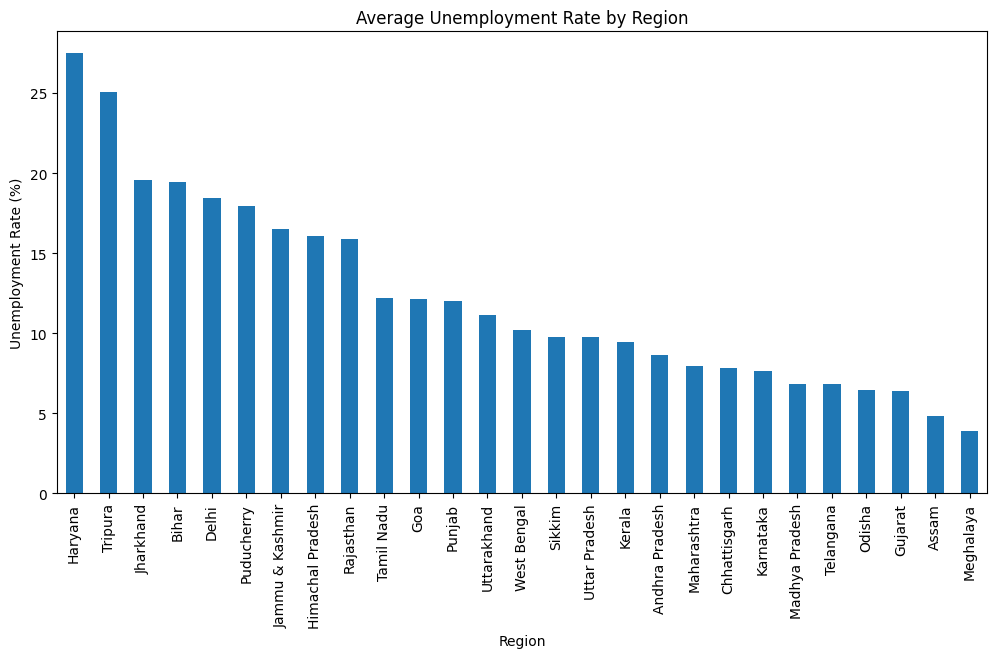

In [59]:
top_regions = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

top_regions = top_regions.sort_values(ascending=False)

top_regions.plot(kind='bar')

plt.title("Average Unemployment Rate by Region")

plt.xlabel("Region")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=90)

plt.show()

# Covid-19 Analysis

In [60]:
covid_data = df[df['Date'] >= '2020-03-01']

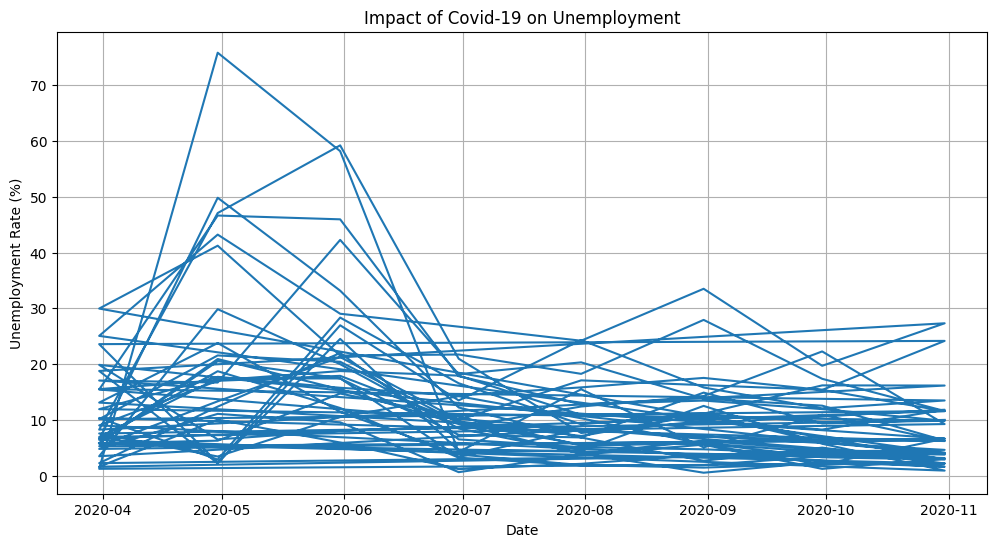

In [61]:
plt.plot(
    covid_data['Date'],
    covid_data['Estimated Unemployment Rate (%)']
)

plt.title("Impact of Covid-19 on Unemployment")

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.grid(True)

plt.show()

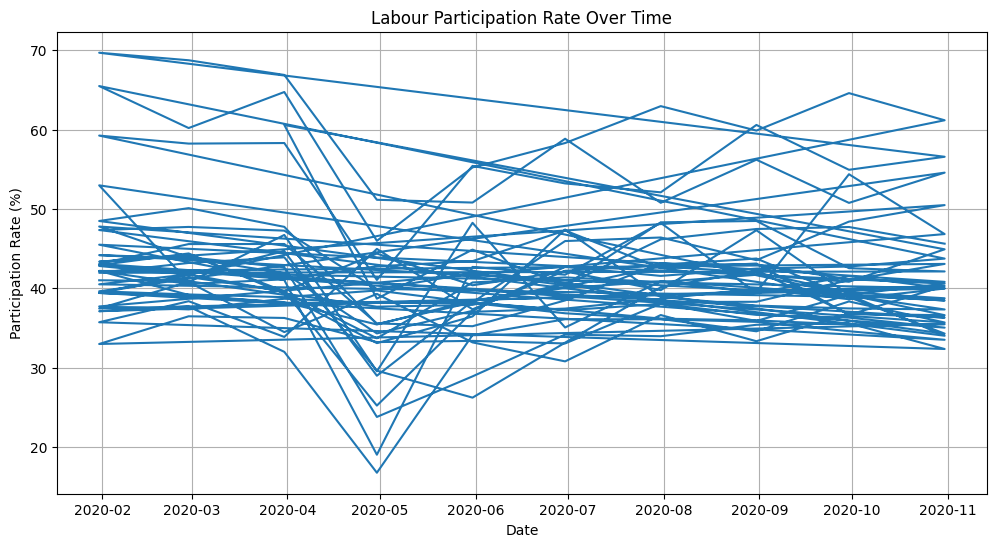

In [62]:
plt.plot(
    df['Date'],
    df['Estimated Labour Participation Rate (%)']
)

plt.title("Labour Participation Rate Over Time")

plt.xlabel("Date")
plt.ylabel("Participation Rate (%)")

plt.grid(True)

plt.show()

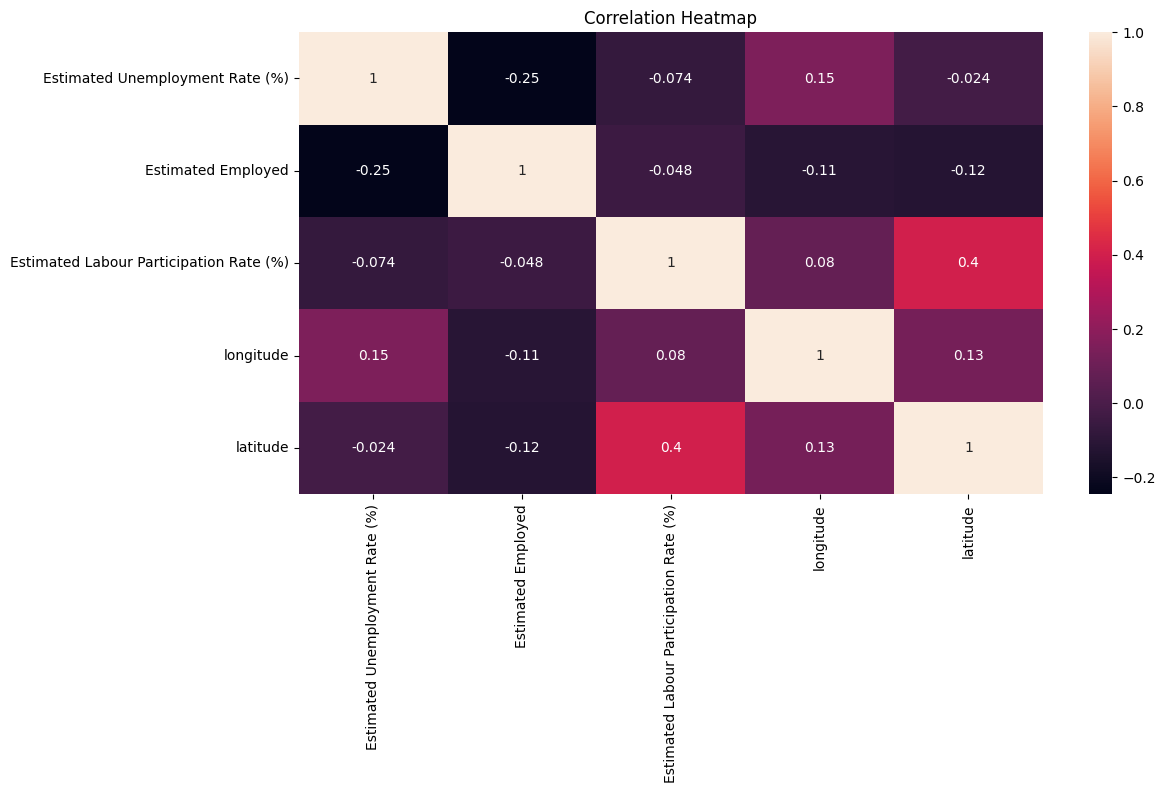

In [63]:
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [64]:
df['Month'] = df['Date'].dt.month

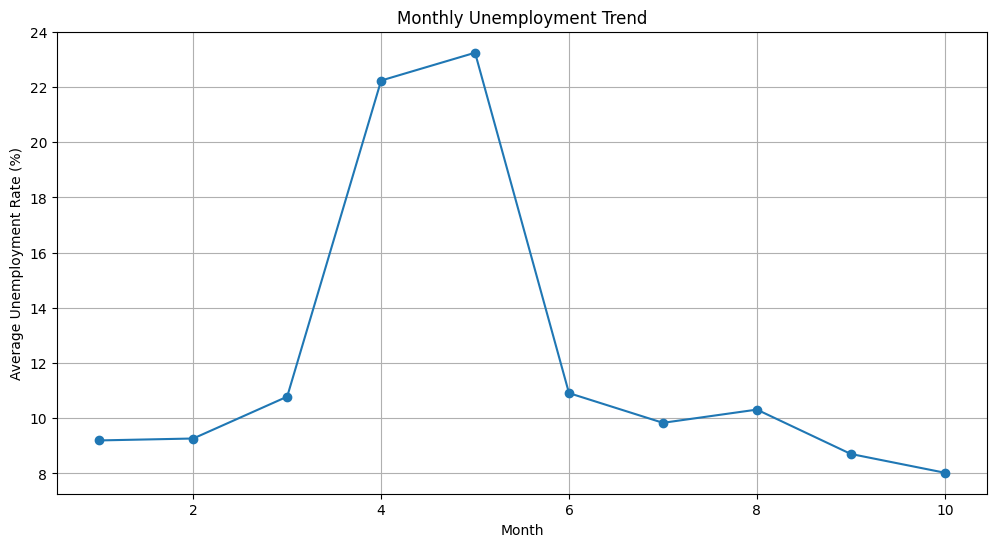

In [65]:
monthly_trend = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

monthly_trend.plot(marker='o')

plt.title("Monthly Unemployment Trend")

plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.grid(True)

plt.show()

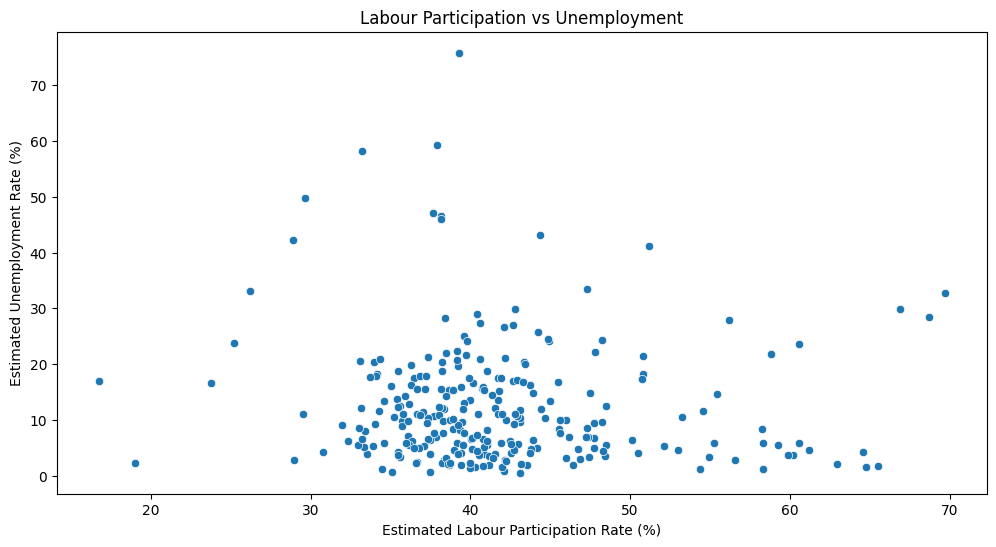

In [66]:
sns.scatterplot(
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Labour Participation vs Unemployment")

plt.show()

# Final Insights and Conclusion

- The unemployment rate increased significantly during the Covid-19 pandemic.
- Certain regions consistently showed higher unemployment rates compared to others.
- Seasonal patterns were observed in monthly unemployment trends.
- Labour participation rate showed correlation with unemployment trends.
- Data visualization helped identify economic impacts and employment fluctuations effectively.

In [1]:
pip install streamlit pandas matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
